# Task_3

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load dataset

In [2]:
df = pd.read_csv('churn_modelling.csv')

In [3]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

##  Cleaning dataset

In [5]:
cols_to_drop = ['RowNumber', 'CustomerId', 'Surname']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

In [6]:
df = df.dropna()


In [7]:
print("Dataset columns:", df.columns.tolist())

Dataset columns: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


## Encoding

In [8]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)


In [9]:
X = df.drop('Exited', axis=1)
y = df['Exited']


## Train Model

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Evaluate

In [13]:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.856
Confusion Matrix:
 [[1549   44]
 [ 244  163]]


### Analyze feature importance

In [16]:
importances = model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values('Importance', ascending=False)


print("\nFeature Importance:\n", importance_df)


Feature Importance:
               Feature  Importance
1                 Age    0.411949
4       NumOfProducts    0.327647
6      IsActiveMember    0.132522
8   Geography_Germany    0.060367
3             Balance    0.054598
7     EstimatedSalary    0.009612
0         CreditScore    0.002279
2              Tenure    0.001026
5           HasCrCard    0.000000
9     Geography_Spain    0.000000
10        Gender_Male    0.000000


## Visualize top features

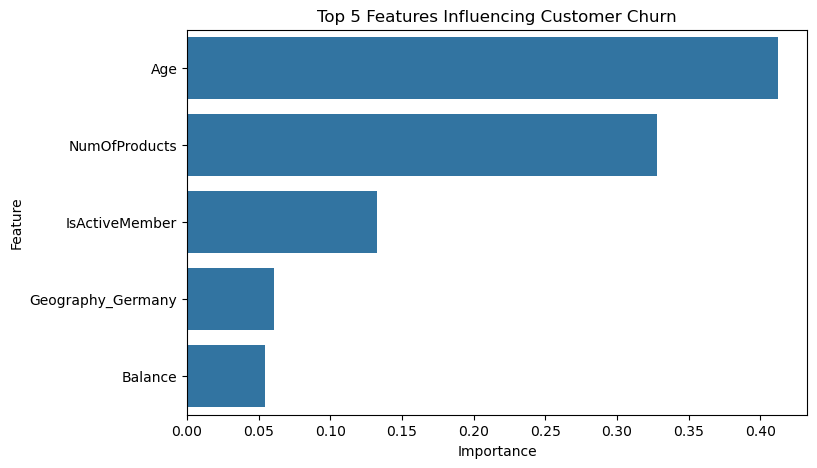

In [17]:
plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df.head(5), x='Importance', y='Feature')
plt.title("Top 5 Features Influencing Customer Churn")
plt.show()